# Simultaneous randomized benchmarking: seeing crosstalk

This example runs the same two-qubit simultaneous RB experiment in two controlled cases: independent noise with **no crosstalk**, and noise with extra individual and shared errors whenever both qubits are driven. The comparison exposes two signatures: simultaneous EPC rising above isolated EPC, and a nonzero pairwise correlation parameter.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

workspace_root = Path.cwd()
while (
    workspace_root != workspace_root.parent
    and not (workspace_root / "pyproject.toml").exists()
):
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from qcmet.benchmarks.gate_execution_quality_metrics.simultaneous_rb import (
    SimultaneousRB,
)
from qcmet.devices import BaseDevice

## A transparent error model

This illustrative statistical device is deliberately simple rather than pulse-level. Each Clifford layer can produce an independent baseline flip on an active qubit. When both qubits are driven, it can also produce extra individual flips and shared flips of both qubits. A shared flip changes each qubit's survival but leaves joint Z parity unchanged; that mismatch is what the correlation parameter detects.

In [2]:
class CrosstalkDevice(BaseDevice):
    """Generate RB-like counts with tunable simultaneous-only errors."""

    def __init__(
        self,
        circuit_metadata,
        baseline_flip=0.006,
        simultaneous_flip=0.0,
        correlated_flip=0.0,
        seed=1234,
    ):
        super().__init__("illustrative_crosstalk_simulator")
        self.circuit_metadata = circuit_metadata
        self.baseline_flip = baseline_flip
        self.simultaneous_flip = simultaneous_flip
        self.correlated_flip = correlated_flip
        self.rng = np.random.default_rng(seed)

    @staticmethod
    def _odd_flip_probability(per_layer_probability, num_layers):
        return (1 - (1 - 2 * per_layer_probability) ** num_layers) / 2

    def _run(self, circuits, num_shots=1024):
        if not isinstance(circuits, list):
            circuits = [circuits]
        if len(circuits) != len(self.circuit_metadata):
            raise ValueError("Circuit metadata does not match the circuit batch")

        all_counts = []
        for metadata in self.circuit_metadata:
            m = metadata["m"]
            simultaneous = metadata["mode"] == "simultaneous"
            active = [0, 1] if simultaneous else [int(metadata["active"][1:])]
            outcomes = np.zeros((num_shots, 2), dtype=np.uint8)

            p_baseline = self._odd_flip_probability(self.baseline_flip, m)
            for qubit in active:
                outcomes[:, qubit] ^= self.rng.random(num_shots) < p_baseline

            if simultaneous:
                p_extra = self._odd_flip_probability(self.simultaneous_flip, m)
                for qubit in active:
                    outcomes[:, qubit] ^= self.rng.random(num_shots) < p_extra

                p_shared = self._odd_flip_probability(self.correlated_flip, m)
                shared = self.rng.random(num_shots) < p_shared
                outcomes[:, 0] ^= shared
                outcomes[:, 1] ^= shared

            bitstrings, frequencies = np.unique(outcomes, axis=0, return_counts=True)
            all_counts.append(
                {
                    f"{bits[0]}{bits[1]}": int(count)
                    for bits, count in zip(bitstrings, frequencies, strict=True)
                }
            )
        return all_counts

## Run matched cases

Both experiments use identical RB settings. The first has only baseline errors. The second adds a 1.2% individual flip probability and a 0.6% shared flip probability per simultaneous layer. These intentionally visible values make the diagnostic behavior easy to recognize.

In [3]:
def run_case(simultaneous_flip, correlated_flip, seed):
    benchmark = SimultaneousRB(
        m_list=[1, 2, 4, 8, 16, 32],
        subsets=[[0], [1]],
        circs_per_m=12,
        seed=7,
    )
    benchmark.generate_circuits()
    metadata = benchmark.experiment_data[["m", "mode", "active"]].to_dict(
        orient="records"
    )
    device = CrosstalkDevice(
        metadata,
        baseline_flip=0.006,
        simultaneous_flip=simultaneous_flip,
        correlated_flip=correlated_flip,
        seed=seed,
    )
    benchmark.run(device=device, num_shots=2048)
    return benchmark, benchmark.analyze()


no_xtalk_benchmark, no_xtalk_result = run_case(0.0, 0.0, seed=10)
xtalk_benchmark, xtalk_result = run_case(0.012, 0.006, seed=11)

## Compare EPC and addressability

Without crosstalk, isolated and simultaneous EPC agree within sampling and fitting uncertainty. With crosstalk, simultaneous EPC and therefore addressability error become clearly larger.

In [4]:
def epc_summary(result):
    return pd.DataFrame(
        {
            "isolated EPC": result["IsolatedEPC"],
            "simultaneous EPC": result["SimultaneousEPC"],
            "addressability error": result["AddressabilityError"],
            "addressability ratio": result["AddressabilityRatio"],
        }
    )


pd.concat(
    {
        "no crosstalk": epc_summary(no_xtalk_result),
        "with crosstalk": epc_summary(xtalk_result),
    },
    names=["case", "subset"],
)

isolated EPC  simultaneous EPC  addressability error  \
case           subset                                                         
no crosstalk   q0          0.008002          0.007070             -0.000932   
               q1          0.006199          0.007992              0.001794   
with crosstalk q0          0.005952          0.023936              0.017983   
               q1          0.007766          0.023748              0.015982   

                       addressability ratio  
case           subset                        
no crosstalk   q0                  0.883555  
               q1                  1.289390  
with crosstalk q0                  4.021166  
               q1                  3.057994

The correlation parameter separates shared errors from a simple increase in independent error. It remains near zero in the first case and becomes positive when shared flips are enabled.

In [5]:
pd.DataFrame(
    {
        "no crosstalk": no_xtalk_result["CorrelationParameter"],
        "with crosstalk": xtalk_result["CorrelationParameter"],
    }
)

,no crosstalk,with crosstalk
q0|q1,-0.000021,0.024658


## Compare decay curves

Open circles and dashed fits are isolated runs; crosses and solid fits are simultaneous runs. The curves overlap without crosstalk. With crosstalk, the simultaneous curves decay faster and visibly separate.

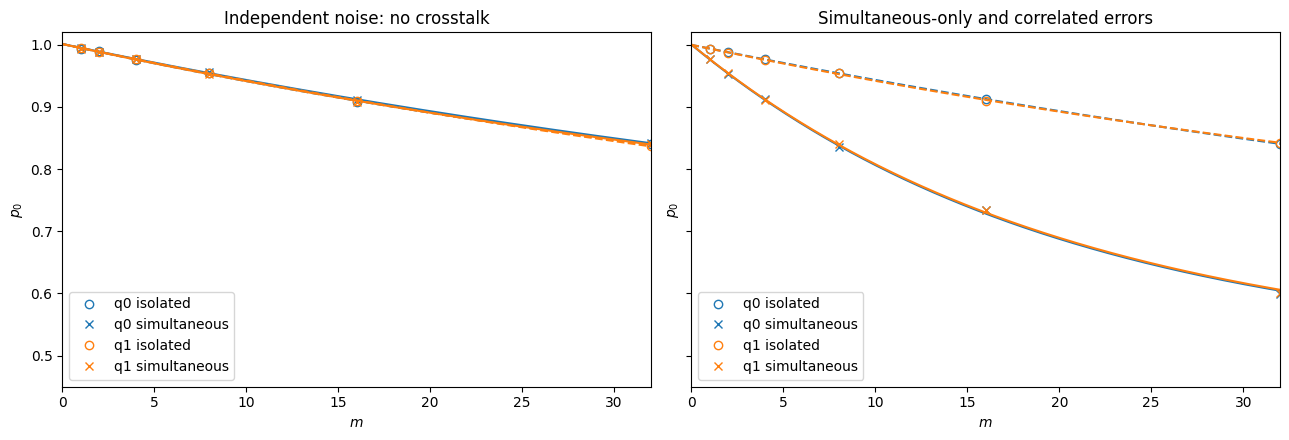

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
no_xtalk_benchmark.plot(axes[0])
xtalk_benchmark.plot(axes[1])
axes[0].set_title("Independent noise: no crosstalk")
axes[1].set_title("Simultaneous-only and correlated errors")
fig.tight_layout()

## Reading a hardware result

On hardware, replace the illustrative device with the appropriate QCMet `BaseDevice`. Look for:

- **curve separation:** simultaneous survival decays faster than isolated survival;
- **positive addressability error:** simultaneous EPC minus isolated EPC exceeds its uncertainty;
- **nonzero correlation parameter:** joint parity decay does not factor into the individual parity decays.

A higher simultaneous EPC alone shows degraded addressability. A nonzero correlation parameter additionally indicates that the errors on the subsets are not independent.